Loading model...
Model loaded.
frame shape: (1080, 1920, 3)

0: 384x640 1 person, 379.4ms
Speed: 1.6ms preprocess, 379.4ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


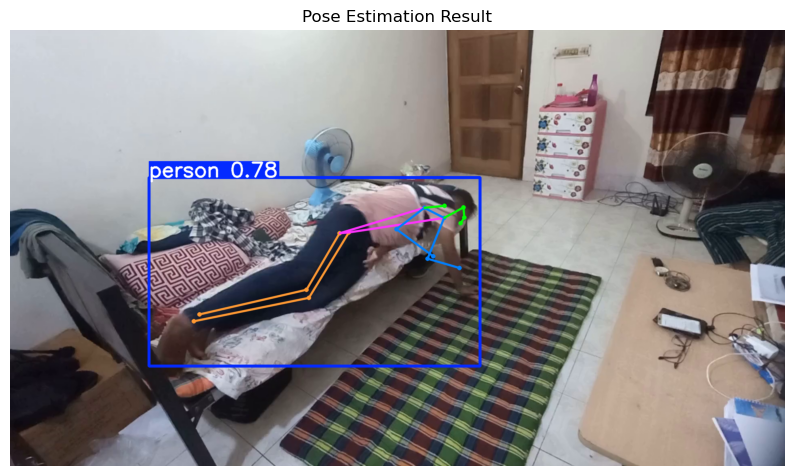

In [3]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import pandas as pd

# Load YOLO model
print("Loading model...")
model = YOLO('yolo11n-pose.pt')
print("Model loaded.")

vid_path = r"example-vid/B_D_0001.mp4"

# Read video frame
cap = cv2.VideoCapture(vid_path)
success, frame = cap.read()
cap.release()

# If frame read successfully
if success:
    print(f"frame shape: {frame.shape}")

    results = model(frame)

    annotated_frame = results[0].plot()

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Pose Estimation Result')
    plt.show()
else:
    print("Failed to read the video frame.")

In [8]:
results = model(frame)

keypoints = results[0].keypoints.data.cpu().numpy()

print(f"# of people detected: {len(keypoints)}")
print(f"\nKeypoints of first person detected:\n{keypoints[0].shape}\n{keypoints[0]}")


0: 384x640 1 person, 6.7ms
Speed: 3.2ms preprocess, 6.7ms inference, 12.2ms postprocess per image at shape (1, 3, 384, 640)
# of people detected: 1

Keypoints of first person detected:
(17, 3)
[[       1116      478.55     0.40478]
 [     1109.8      467.76     0.14828]
 [     1125.9      464.46     0.28776]
 [       1077      435.35     0.36661]
 [     1123.4      439.65     0.65958]
 [     1026.6      440.49     0.96229]
 [       1075      465.84     0.98287]
 [     957.48      493.25     0.74513]
 [     1034.3      566.85     0.92922]
 [     1048.5      560.58     0.52653]
 [       1114      589.31     0.74646]
 [     816.66      503.69     0.98979]
 [     839.33      501.11     0.99281]
 [     734.05      643.92      0.9752]
 [     740.59      663.77     0.98312]
 [     469.35         704     0.92921]
 [     455.23      721.47     0.94116]]


In [10]:
data_rows = []
keypoint_names = ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
                  'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
                  'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
                  'left_knee', 'right_knee', 'left_ankle', 'right_ankle']

for person_id, person_keypoints in enumerate(keypoints):
    for kp_id, (x, y, c) in enumerate(person_keypoints):
        data_rows.append({
            'person_id': person_id,
            'keypoint_id': kp_id,
            'keypoint_name': keypoint_names[kp_id],
            'x': float(x),
            'y': float(y),
            'confidence': float(c)
        })

df = pd.DataFrame(data_rows)
df.to_csv('pose_keypoints_frame1.csv', index=False)
print("Keypoints saved to 'pose_keypoints_frame1.csv'.")

Keypoints saved to 'pose_keypoints_frame1.csv'.
